# ARX Model – Greenhouse Soil Moisture Prediction
## Notebook thực hành đầy đủ

**ARX(2, 2, 1)** | MISO | Least Squares | Preprocessing | Model Evaluation

---
### Cấu trúc Notebook
| # | Phần | Mô tả |
|---|------|-------|
| 1 | Setup | Cài đặt thư viện |
| 2 | Lý thuyết | Mô hình ARX, phương trình |
| 3 | Dữ liệu | Tạo / tải + **Preprocessing** (lọc nhiễu, chuẩn hóa) |
| 4 | Regression Matrix | Xây dựng ma trận X, Y |
| 5 | Ước lượng tham số | Least Squares |
| 6 | Dự đoán | One-step & Simulation |
| 7 | Đánh giá | RMSE, FIT, R², AIC, BIC |
| 8 | Residuals | Phân tích phần dư |
| 9 | Model Selection | So sánh các bậc mô hình |
| 10 | Kết luận | Tổng kết & hướng mở rộng |

# 1. Setup & Import Thư Viện
Cài đặt các thư viện cần thiết. Nếu chưa cài, chạy cell bên dưới.

In [1]:
# Cài đặt (bỏ comment nếu cần)
# !pip install numpy pandas matplotlib scipy scikit-learn statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('✅ Libraries imported successfully')
print(f'NumPy:  {np.__version__}')
print(f'Pandas: {pd.__version__}')


✅ Libraries imported successfully
NumPy:  2.4.2
Pandas: 3.0.1


# 2. Lý Thuyết ARX Model

## 2.1 Định nghĩa
Mô hình **ARX(na, nb, nk)** có dạng tổng quát:
$$A(q)\,y(t) = B(q)\,u(t) + e(t)$$

Trong đó:
- $q^{-1}$: toán tử dịch chuyển sau – $q^{-1}y(t)=y(t-1)$
- $A(q) = 1 + a_1q^{-1} + a_2q^{-2}$: đa thức AR
- $B(q) = b_1q^{-n_k} + b_2q^{-n_k-1}$: đa thức eXogenous
- $e(t)$: nhiễu trắng (white noise)

## 2.2 Hệ thống MISO
```
INPUTS:                          OUTPUT:
  Temperature(t)   ─┐
  Humidity(t)      ─┤
  Light(t)         ─┤──► [ARX(2,2,1)] ──► Soil Moisture(t)
  Drip(t)          ─┤
  Mist(t)          ─┤
  Fan(t)           ─┘
```

## 2.3 Phương trình đầy đủ ARX(2,2,1)
$$\text{Soil}(t) = a_1 y(t-1) + a_2 y(t-2)$$
$$+ b_1 T(t-1) + b_2 T(t-2)$$
$$+ b_3 H(t-1) + b_4 H(t-2)$$
$$+ b_5 L(t-1) + b_6 L(t-2)$$
$$+ b_7 D(t-1) + b_8 D(t-2)$$
$$+ b_9 M(t-1) + b_{10} M(t-2)$$
$$+ b_{11} F(t-1) + b_{12} F(t-2) + e(t)$$

**Tổng: 14 tham số** = 2 (AR) + 12 (6 inputs × 2 lags)

## 2.4 Dạng hồi quy tuyến tính
$$y(t) = \varphi(t)^T \theta + e(t)$$

$$\varphi(t) = [y(t-1),\, y(t-2),\, u_1(t-1),\, u_1(t-2),\, \ldots,\, u_6(t-1),\, u_6(t-2)]^T \in \mathbb{R}^{14}$$

## 2.5 Ước lượng Least Squares
$$\hat{\theta} = (X^TX)^{-1}X^TY$$

Tối thiểu hóa: $\min_{\theta} \|Y - X\theta\|^2$

# 3. Dữ Liệu Greenhouse
## 3.1 Tạo dữ liệu tổng hợp (Synthetic Data)
Dùng để kiểm tra pipeline khi chưa có dữ liệu thực.
Dữ liệu được tạo với **tham số đã biết** để kiểm chứng độ chính xác.

In [3]:
def generate_greenhouse_data(N=3000, T_s=60, seed=42):
    """
    Tạo dữ liệu nhà kính tổng hợp.
    
    Args:
        N:    số mẫu
        T_s:  sampling period (giây)
        seed: random seed
    Returns:
        df (DataFrame), true_params (dict)
    """
    np.random.seed(seed)
    t = np.arange(N)
    period_day = 24 * 3600 / T_s  # samples per day

    # ── TRUE PARAMETERS ──────────────────────────────────────
    TRUE = {
        'a1': 0.85, 'a2': -0.12,
        'b_temp': -0.8, 'b_humi': 0.3,
        'b_light': 0.02, 'b_drip': 5.0,
        'b_mist': 3.0, 'b_fan': -2.0,
    }

    # ── INPUTS ───────────────────────────────────────────────
    Temp  = 25 + 6*np.sin(2*np.pi*t/period_day) + np.random.normal(0, 1, N)
    Humi  = 70 + 15*np.cos(2*np.pi*t/period_day) + np.random.normal(0, 2, N)
    Light = np.clip(1200*np.sin(np.pi*(t % period_day)/period_day),
                    0, None) + np.random.normal(0, 30, N)
    Light = np.clip(Light, 0, 1500)

    # Actuators: random switching
    Drip = (np.random.random(N) > 0.85).astype(float)   # 15%
    Mist = (np.random.random(N) > 0.92).astype(float)   # 8%
    Fan  = (np.random.random(N) > 0.70).astype(float)   # 30%

    # ── OUTPUT: Soil Moisture ─────────────────────────────────
    y = np.zeros(N)
    y[0], y[1] = 65.0, 64.8

    for i in range(2, N):
        y[i] = (TRUE['a1'] * y[i-1] + TRUE['a2'] * y[i-2]
                + TRUE['b_temp']  * Temp[i-1]
                + TRUE['b_humi']  * Humi[i-1]
                + TRUE['b_light'] * Light[i-1]
                + TRUE['b_drip']  * Drip[i-1]
                + TRUE['b_mist']  * Mist[i-1]
                + TRUE['b_fan']   * Fan[i-1]
                + np.random.normal(0, 0.25))
        y[i] = np.clip(y[i], 0, 100)

    df = pd.DataFrame({
        'Timestamp':     pd.date_range('2025-01-01', periods=N, freq=f'{T_s}s'),
        'Soil_Moisture': y,
        'Temperature':   Temp,
        'Humidity':      Humi,
        'Light':         Light,
        'Drip':          Drip,
        'Mist':          Mist,
        'Fan':           Fan,
    })
    return df, TRUE


df, TRUE_PARAMS = generate_greenhouse_data(N=3000, T_s=60)
print(f'Dataset shape: {df.shape}')
print(f"Date range   : {df['Timestamp'].iloc[0]}  →  {df['Timestamp'].iloc[-1]}")
print('\nTrue parameters used for generation:')
for k, v in TRUE_PARAMS.items():
    print(f'  {k:12s} = {v:+.4f}')
df.head()


Dataset shape: (3000, 8)
Date range   : 2025-01-01 00:00:00  →  2025-01-03 01:59:00

True parameters used for generation:
  a1           = +0.8500
  a2           = -0.1200
  b_temp       = -0.8000
  b_humi       = +0.3000
  b_light      = +0.0200
  b_drip       = +5.0000
  b_mist       = +3.0000
  b_fan        = -2.0000


,Timestamp,Soil_Moisture,Temperature,Humidity,Light,Drip,Mist,Fan
0,2025-01-01 00:00:00,65.000000,25.496714,81.184385,0.000000,0.0,1.0,0.0
1,2025-01-01 00:01:00,64.800000,24.887916,83.279087,0.000000,0.0,0.0,0.0
2,2025-01-01 00:02:00,52.300812,25.700048,84.172218,0.000000,0.0,0.0,0.0
3,2025-01-01 00:03:00,41.129503,26.601567,88.774090,0.000000,0.0,0.0,1.0
4,2025-01-01 00:04:00,32.132575,24.870561,86.110822,4.047333,0.0,0.0,1.0


## 3.2 Thống kê mô tả dữ liệu

In [4]:
print('=== Descriptive Statistics ===')
print(df.describe().round(3).to_string())


=== Descriptive Statistics ===
                 Timestamp  Soil_Moisture  Temperature  Humidity     Light      Drip      Mist       Fan
count                 3000       3000.000     3000.000  3000.000  3000.000  3000.000  3000.000  3000.000
mean   2025-01-02 00:59:30         60.285       25.093    70.497   739.822     0.157     0.077     0.313
min    2025-01-01 00:00:00         14.709       16.129    50.379     0.000     0.000     0.000     0.000
25%    2025-01-01 12:29:45         42.387       21.143    60.012   403.733     0.000     0.000     0.000
50%    2025-01-02 00:59:30         61.350       25.263    70.875   818.708     0.000     0.000     0.000
75%    2025-01-02 13:29:15         79.999       29.016    81.033  1098.398     0.000     0.000     1.000
max    2025-01-03 01:59:00        100.000       33.597    90.690  1289.713     1.000     1.000     1.000
std                    NaN         21.289        4.264    10.907   382.314     0.364     0.266     0.464


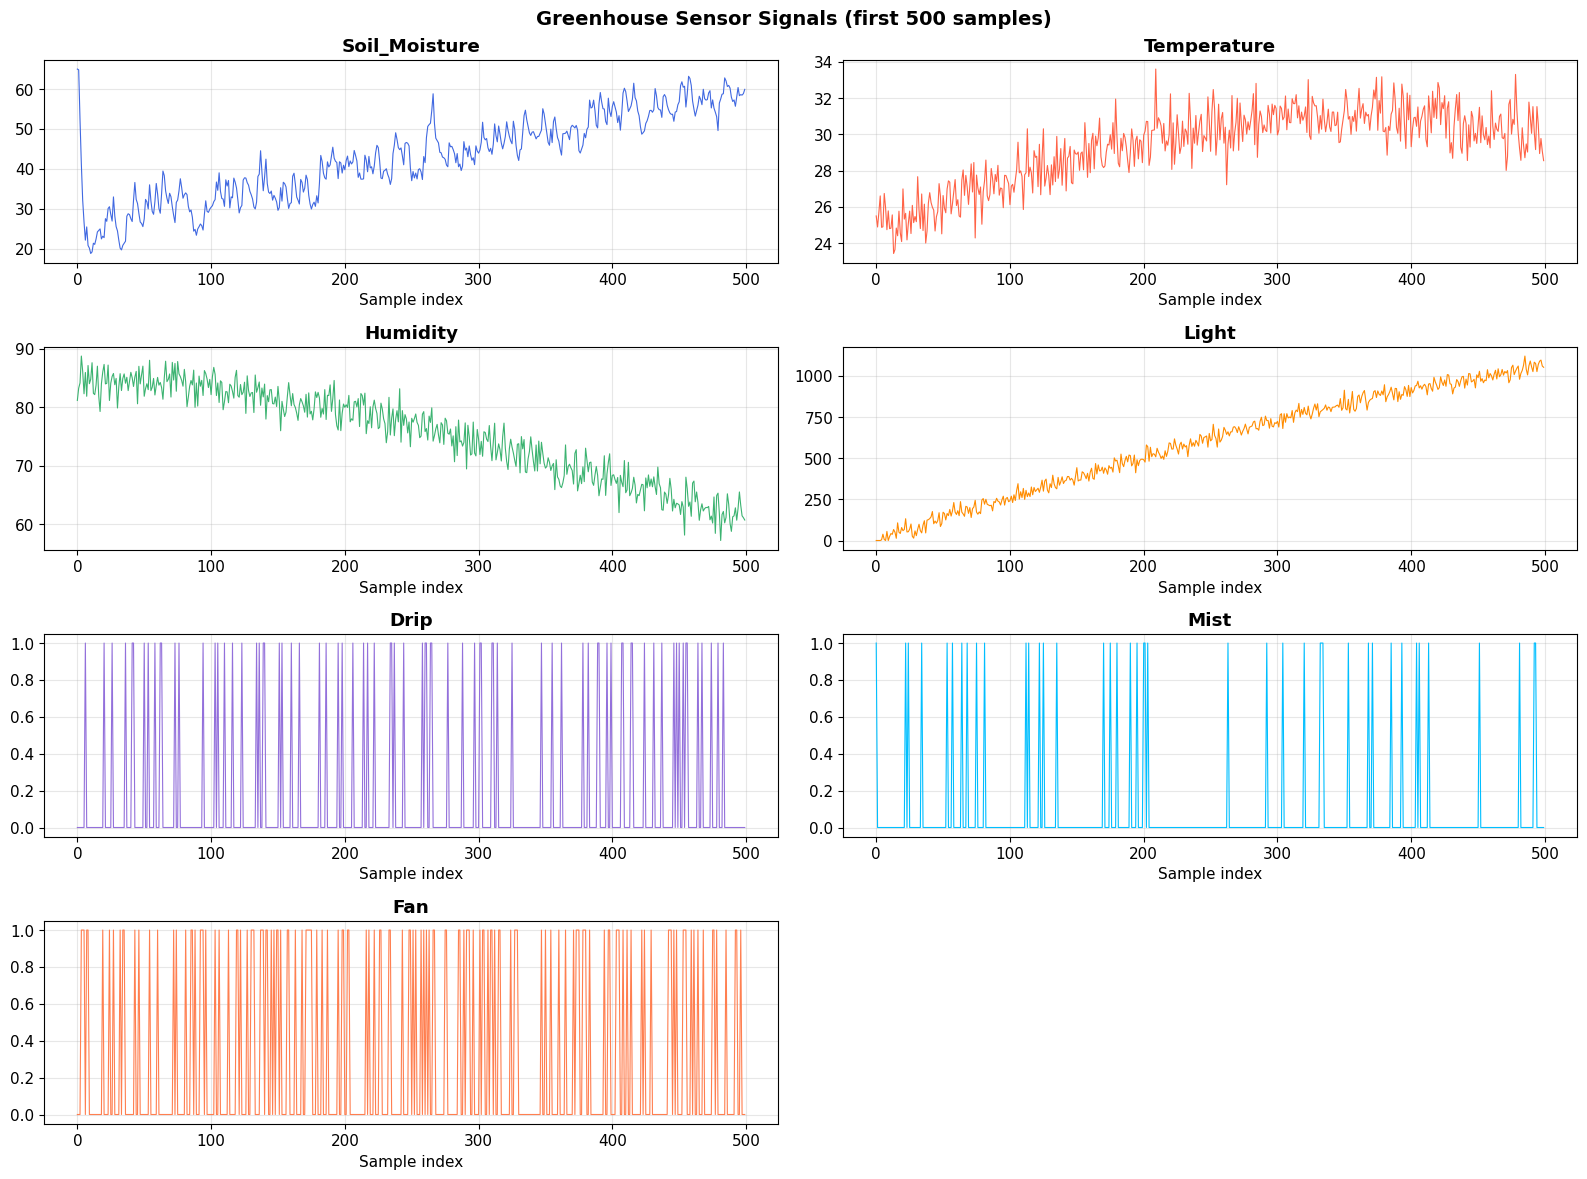

In [5]:
# Visualize all signals
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
cols  = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan']
colors= ['royalblue', 'tomato', 'mediumseagreen', 'darkorange',
          'mediumpurple', 'deepskyblue', 'coral']
axes_flat = axes.flatten()
for i, (col, c) in enumerate(zip(cols, colors)):
    axes_flat[i].plot(df[col].values[:500], color=c, linewidth=0.8)
    axes_flat[i].set_title(col, fontweight='bold')
    axes_flat[i].set_xlabel('Sample index')
axes_flat[-1].set_visible(False)
fig.suptitle('Greenhouse Sensor Signals (first 500 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.3 Tải dữ liệu thực (nếu có)
```python
# Chỉ dùng khi có file CSV thực từ hệ thống nhà kính
# df = pd.read_csv('greenhouse_data.csv', parse_dates=['Timestamp'])
# df = df.sort_values('Timestamp').dropna().reset_index(drop=True)
```

**Format yêu cầu:**
```
Timestamp,Soil_Moisture,Temperature,Humidity,Light,Drip,Mist,Fan
2025-01-01 00:00:00,65.2,24.1,72.3,0,0,0,1
...
```

## 3.4 Lọc Nhiễu (Noise Filtering)

Dữ liệu cảm biến thực tế thường chứa nhiễu đo lường. Bước này dùng **Savitzky-Golay filter** để làm mịn tín hiệu liên tục (Temperature, Humidity, Light, Soil_Moisture) trước khi đưa vào mô hình.

| Loại tín hiệu | Xử lý |
|--------------|-------|
| Soil_Moisture, Temperature, Humidity, Light | Savitzky-Golay (window=11, poly=3) |
| Drip, Mist, Fan (binary 0/1) | Giữ nguyên – không lọc |

> **Tại sao Savitzky-Golay?**  
> Bảo toàn các đỉnh (peak) và xu hướng tốt hơn moving average, phù hợp cho tín hiệu sinh học/môi trường.


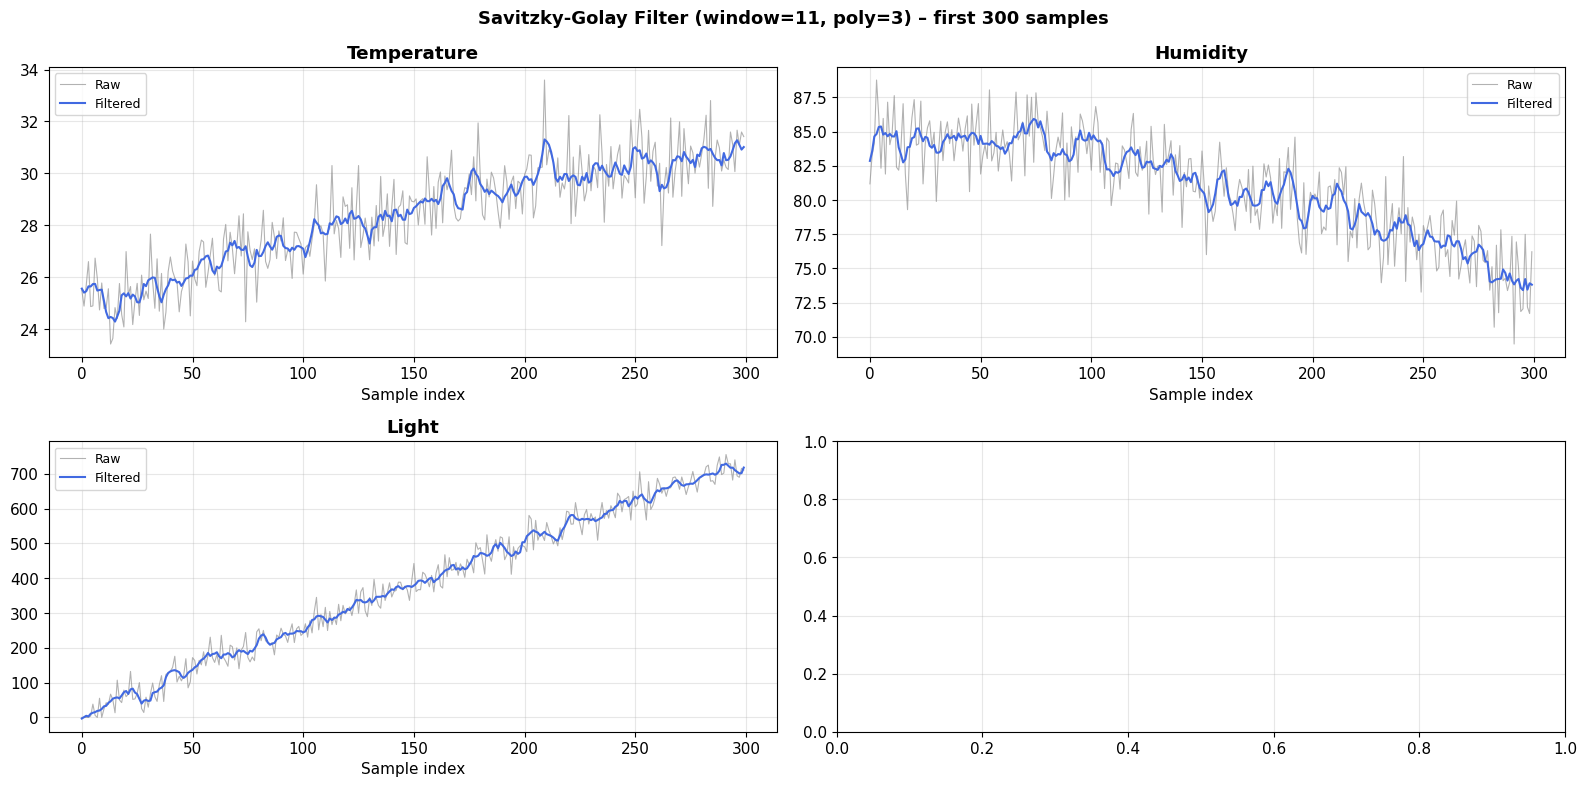

=== Noise Reduction ===
  Temperature      noise std: 0.8878 → 0.3058  (65.6% reduction)
  Humidity         noise std: 1.8168 → 0.6145  (66.2% reduction)
  Light            noise std: 27.6943 → 10.2439  (63.0% reduction)

✅ Filtering done. Using df_filtered for all downstream steps.


In [6]:
from scipy.signal import savgol_filter

# ── CONFIG ────────────────────────────────────────────────────
FILTER_WINDOW  = 11   # nên là số lẻ; tăng lên để lọc mạnh hơn
FILTER_POLY    = 3    # bậc đa thức (3 hoặc 5 là phổ biến)
# ⚠️ QUAN TRỌNG: KHÔNG lọc Soil_Moisture (output y)!
# Lọc y trước khi fit sẽ làm mất noise dynamics thật → sigma² giả tạo nhỏ, FIT% ảo
CONTINUOUS_COLS = ['Temperature', 'Humidity', 'Light']  # CHỈ lọc inputs
BINARY_COLS     = ['Drip', 'Mist', 'Fan']   # không lọc binary signals

df_filtered = df.copy()

for col in CONTINUOUS_COLS:
    df_filtered[col] = savgol_filter(
        df[col].values,
        window_length=FILTER_WINDOW,
        polyorder=FILTER_POLY,
        mode='nearest'        # xử lý biên
    )

# ── VISUALIZE: Before vs After filtering ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, col in zip(axes.flatten(), CONTINUOUS_COLS):
    n_show = 300
    ax.plot(df[col].values[:n_show],          'gray', lw=0.8, alpha=0.6, label='Raw')
    ax.plot(df_filtered[col].values[:n_show], 'royalblue', lw=1.5, label='Filtered')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Sample index')

fig.suptitle(f'Savitzky-Golay Filter (window={FILTER_WINDOW}, poly={FILTER_POLY}) – first 300 samples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate noise reduction
print('=== Noise Reduction ===')
for col in CONTINUOUS_COLS:
    noise_before = (df[col] - df[col].rolling(5).mean()).std()
    noise_after  = (df_filtered[col] - df_filtered[col].rolling(5).mean()).std()
    reduction = (1 - noise_after / noise_before) * 100 if noise_before > 0 else 0
    print(f'  {col:<15}  noise std: {noise_before:.4f} → {noise_after:.4f}  '
          f'({reduction:.1f}% reduction)')

print('\n✅ Filtering done. Using df_filtered for all downstream steps.')
df = df_filtered  # Replace raw df


## 3.5 Chuẩn Hóa Dữ Liệu (Normalization)

**Tại sao cần chuẩn hóa?**
- `Light` có giá trị ~0–1500 lux, `Drip` chỉ là 0/1 → **chênh lệch scale 1500 lần**
- Khi không chuẩn hóa, `Light` sẽ **dominate** regression matrix, làm các tham số nhỏ khó ước lượng
- Condition number của X sẽ rất lớn → **không ổn định số học**

**Phương pháp: Min-Max Scaling** (fit trên train, áp lên val):
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}} \in [0, 1]$$

> ⚠️ **Quan trọng:** Fit scaler TRÊN TRAIN rồi apply lên VAL (tránh data leakage)


In [7]:
# ── MIN-MAX SCALER ───────────────────────────────────────────
ALL_FEATURE_COLS = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light']
# Binary cols (Drip, Mist, Fan) đã ở thang 0-1, không cần scale

# Fit on training portion (before split)
N_total = len(df)
TRAIN_RATIO = 0.70
n_train = int(N_total * TRAIN_RATIO)

scaler_min = df.iloc[:n_train][ALL_FEATURE_COLS].min()
scaler_max = df.iloc[:n_train][ALL_FEATURE_COLS].max()
scaler_range = scaler_max - scaler_min

def normalize(df_in, cols=ALL_FEATURE_COLS):
    df_out = df_in.copy()
    df_out[cols] = (df_in[cols] - scaler_min) / scaler_range
    return df_out

def denormalize_y(y_norm):
    """Chuyển soil moisture từ normalized về đơn vị %"""
    return y_norm * scaler_range['Soil_Moisture'] + scaler_min['Soil_Moisture']

df_norm = normalize(df)

# ── Show before/after ─────────────────────────────────────────
print('=== Scaling Info (fit on training set) ===')
for col in ALL_FEATURE_COLS:
    print(f'  {col:<15}  min={scaler_min[col]:.3f}  max={scaler_max[col]:.3f}  '
          f'range={scaler_range[col]:.3f}')

print('\n=== Normalized Statistics (should be ≈ [0, 1]) ===')
print(df_norm[ALL_FEATURE_COLS + BINARY_COLS].describe().round(3).to_string())

# Condition number comparison
from numpy.linalg import cond, matrix_rank

def quick_cond(df_in, na=2, nb=2, nk=1):
    n = int(len(df_in) * TRAIN_RATIO)
    df_tr = df_in.iloc[:n]
    X, _ = build_regression_matrix(df_tr, na, nb, nk) if 'build_regression_matrix' in dir() else (None, None)
    return cond(X.T @ X) if X is not None else float('nan')

print('\n💡 Condition number will be computed after build_regression_matrix is defined (Section 4).')
print('✅ Normalization done. Using df_norm for all downstream steps.')
df = df_norm  # Replace filtered df with normalized df


=== Scaling Info (fit on training set) ===
  Soil_Moisture    min=16.370  max=100.000  range=83.630
  Temperature      min=18.060  max=32.437  range=14.377
  Humidity         min=52.822  max=86.723  range=33.901
  Light            min=-3.121  max=1232.957  range=1236.078

=== Normalized Statistics (should be ≈ [0, 1]) ===
       Soil_Moisture  Temperature  Humidity     Light      Drip      Mist       Fan
count       3000.000     3000.000  3000.000  3000.000  3000.000  3000.000  3000.000
mean           0.525        0.489     0.521     0.601     0.157     0.077     0.313
std            0.255        0.290     0.317     0.309     0.364     0.266     0.464
min           -0.020        0.000     0.000     0.000     0.000     0.000     0.000
25%            0.311        0.210     0.204     0.331     0.000     0.000     0.000
50%            0.538        0.504     0.539     0.667     0.000     0.000     0.000
75%            0.761        0.768     0.839     0.893     0.000     0.000     1.000
max 

# 4. Phân Chia Dữ Liệu & Xây Dựng Ma Trận Hồi Quy
## 4.1 Train / Validation Split
Dùng **phân chia tuần tự theo thời gian** (không shuffle) để tránh data leakage.
```
┌───────────────────────────────────────────────────┐
│              Full Dataset (N = 3000)               │
│  DS1 – Training (70%)  │  DS2 – Validation (30%)  │
│       2100 samples      │       900 samples        │
└───────────────────────────────────────────────────┘
```

In [8]:
# ── CONFIG ──────────────────────────────────────────────────
NA = 2   # AR order
NB = 2   # input order
NK = 1   # input delay
TRAIN_RATIO = 0.70

# ── SPLIT ────────────────────────────────────────────────────
N_total = len(df)
n_train = int(N_total * TRAIN_RATIO)
df_train = df.iloc[:n_train].copy()
df_val   = df.iloc[n_train:].copy().reset_index(drop=True)

print(f'Total samples : {N_total}')
print(f'Training (DS1): {len(df_train)} samples  ({TRAIN_RATIO*100:.0f}%)')
print(f'Validation(DS2): {len(df_val)} samples  ({(1-TRAIN_RATIO)*100:.0f}%)')


Total samples : 3000
Training (DS1): 2100 samples  (70%)
Validation(DS2): 900 samples  (30%)


## 4.2 Xây dựng Regression Matrix X và Output Vector Y

$$X = \begin{bmatrix} \varphi(3)^T \\ \varphi(4)^T \\ \vdots \\ \varphi(N)^T \end{bmatrix} \in \mathbb{R}^{(N-2) \times 14}, \quad Y = \begin{bmatrix} y(3) \\ y(4) \\ \vdots \\ y(N) \end{bmatrix} \in \mathbb{R}^{N-2}$$

In [9]:
INPUT_COLS = ['Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan']
OUTPUT_COL = 'Soil_Moisture'


def build_regression_matrix(df, na=2, nb=2, nk=1,
                             input_cols=INPUT_COLS, output_col=OUTPUT_COL):
    """
    Xây dựng ma trận hồi quy X và vector Y cho ARX(na, nb, nk).

    Returns:
        X : (N_eff × n_params) regression matrix
        Y : (N_eff,)            output vector
    """
    y = df[output_col].values
    Us = [df[c].values for c in input_cols]
    n_inputs = len(Us)

    max_lag = max(na, nb + nk - 1)
    N       = len(y)
    N_eff   = N - max_lag
    n_params = na + n_inputs * nb + 1

    X = np.zeros((N_eff, n_params))
    Y = np.zeros(N_eff)

    for i in range(N_eff):
        t   = i + max_lag
        row = []
        # AR terms
        for lag in range(1, na + 1):
            row.append(y[t - lag])
        # eXogenous terms
        for u in Us:
            for lag in range(nk, nk + nb):
                row.append(u[t - lag])
        row.append(1.0)
        X[i] = row
        Y[i] = y[t]

    return X, Y


X_train, Y_train = build_regression_matrix(df_train, NA, NB, NK)
X_val,   Y_val   = build_regression_matrix(df_val,   NA, NB, NK)

print(f'X_train shape : {X_train.shape}  (N_eff × n_params)')
print(f'Y_train shape : {Y_train.shape}')
print(f'X_val   shape : {X_val.shape}')

# Check rank
rank = np.linalg.matrix_rank(X_train)
cond = np.linalg.cond(X_train.T @ X_train)
print(f'\nRank of X_train  : {rank} / {X_train.shape[1]}  (phải bằng nhau)')
print(f'Condition number : {cond:.2f}  (nên < 1e6)')

# Column names
PARAM_NAMES = (['a1','a2'] +
               [f'b_{c}_{l}' for c in INPUT_COLS for l in range(1, NB+1)] +
               ['intercept'])
print(f'\nParameter names ({len(PARAM_NAMES)} total):')
print(PARAM_NAMES)


X_train shape : (2098, 15)  (N_eff × n_params)
Y_train shape : (2098,)
X_val   shape : (898, 15)

Rank of X_train  : 15 / 15  (phải bằng nhau)
Condition number : 200214.62  (nên < 1e6)

Parameter names (15 total):
['a1', 'a2', 'b_Temperature_1', 'b_Temperature_2', 'b_Humidity_1', 'b_Humidity_2', 'b_Light_1', 'b_Light_2', 'b_Drip_1', 'b_Drip_2', 'b_Mist_1', 'b_Mist_2', 'b_Fan_1', 'b_Fan_2', 'intercept']


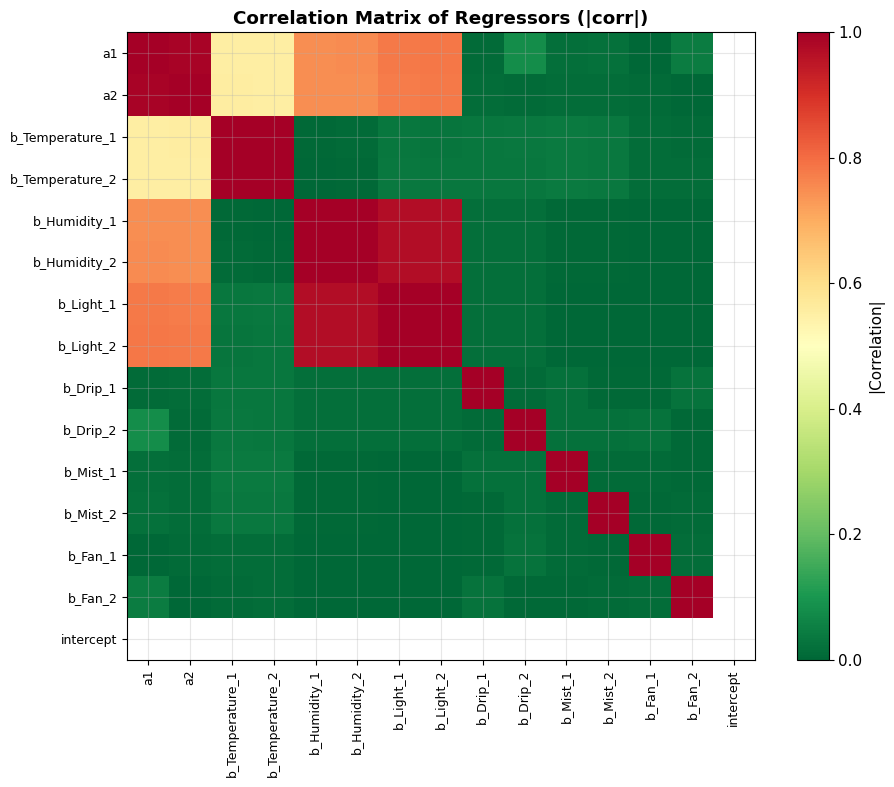

High correlation (>0.8) may indicate multicollinearity issues.


In [10]:
# Correlation heatmap of regression matrix
import matplotlib.pyplot as plt

corr = np.corrcoef(X_train.T)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.abs(corr), cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(len(PARAM_NAMES)))
ax.set_yticks(range(len(PARAM_NAMES)))
ax.set_xticklabels(PARAM_NAMES, rotation=90, fontsize=9)
ax.set_yticklabels(PARAM_NAMES, fontsize=9)
plt.colorbar(im, ax=ax, label='|Correlation|')
ax.set_title('Correlation Matrix of Regressors (|corr|)', fontweight='bold')
plt.tight_layout()
plt.show()
print('High correlation (>0.8) may indicate multicollinearity issues.')


# 5. Ước Lượng Tham Số – Least Squares
## 5.1 Ordinary Least Squares (OLS)
$$\hat{\theta} = (X^TX)^{-1}X^TY$$

**Tính chất:** $\hat{\theta}$ là BLUE (Best Linear Unbiased Estimator) theo định lý Gauss-Markov.

**Uncertainty:** $\text{Cov}(\hat{\theta}) = \sigma^2 (X^TX)^{-1}$

In [11]:
def estimate_ols(X, Y):
    """
    Ordinary Least Squares estimation.
    Returns: theta, cov_matrix, sigma2
    """
    # lstsq is numerically more stable than pinv
    theta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

    N, k   = X.shape
    Y_pred = X @ theta
    resid  = Y - Y_pred
    sigma2 = np.dot(resid, resid) / (N - k)   # unbiased estimator
    cov    = sigma2 * np.linalg.pinv(X.T @ X)

    return theta, cov, sigma2


theta_hat, cov_hat, sigma2_hat = estimate_ols(X_train, Y_train)
std_hat = np.sqrt(np.diag(cov_hat))

# ── DENORMALIZE THETA về không gian gốc ─────────────────────
# Trong normalized space: y_n = a*y_n_lag + b_n*u_n_lag
# AR coefs (a1, a2) KHÔNG đổi (ratio y/y → scale cancel)
# b coefs: b_orig = b_norm * (y_range / u_range)
# Binary inputs (Drip, Mist, Fan) không được normalize → u_range = 1
# → b_binary_orig = b_norm * y_range

# Build scale vector cho từng tham số
theta_scale = []
for name in PARAM_NAMES:
    if name.startswith('a'):   # AR terms: scale = 1
        theta_scale.append(1.0)
    elif name == 'intercept':
        theta_scale.append(float(scaler_range['Soil_Moisture']))
    else:                       # b_InputName_lag
        # tên dạng 'b_Temperature_1' → input = 'Temperature'
        input_name = '_'.join(name.split('_')[1:-1])
        if input_name in scaler_range.index:  # input được normalize
            u_rng = float(scaler_range[input_name])
            theta_scale.append(float(scaler_range['Soil_Moisture']) / u_rng)
        else:                                  # binary: range = 1
            theta_scale.append(float(scaler_range['Soil_Moisture']))

theta_orig = theta_hat * np.array(theta_scale)  # theta trong đơn vị gốc (%)
sigma2_orig = sigma2_hat * float(scaler_range['Soil_Moisture'])**2  # var trong đơn vị %

print(f'Estimated noise σ (normalized): {np.sqrt(sigma2_hat):.6f}')
print(f'Estimated noise σ (original %): {np.sqrt(sigma2_orig):.4f} %  [true ≈ 0.25 %]\n')

print(f'{"Param":<15} {"θ̂_norm":>12}  {"θ̂_orig (%)":>13}  [TRUE (if known)]')
print('-' * 70)

# TRUE_PARAMS ở space gốc (%) – so sánh trực tiếp với theta_orig
true_ref = {
    'a1': TRUE_PARAMS['a1'],    'a2': TRUE_PARAMS['a2'],
    'b_Drip_1':  TRUE_PARAMS['b_drip'],
    'b_Temperature_1': TRUE_PARAMS['b_temp'],
}

for name, th_n, th_o in zip(PARAM_NAMES, theta_hat, theta_orig):
    ref   = true_ref.get(name, float('nan'))
    ref_s = f'{ref:+.4f}' if not np.isnan(ref) else '  —'
    match = ' ✅' if (not np.isnan(ref) and abs(th_o - ref) < 0.05) else (' ⚠️' if not np.isnan(ref) else '')
    print(f'{name:<15} {th_n:+12.6f}  {th_o:+13.6f}  {ref_s}{match}')


Estimated noise σ (normalized): 0.012388
Estimated noise σ (original %): 1.0360 %  [true ≈ 0.25 %]

Param                θ̂_norm    θ̂_orig (%)  [TRUE (if known)]
----------------------------------------------------------------------
a1                 +0.569420      +0.569420  +0.8500 ⚠️
a2                 +0.058173      +0.058173  -0.1200 ⚠️
b_Temperature_1    -0.099684      -0.579841  -0.8000 ⚠️
b_Temperature_2    -0.089662      -0.521545    —
b_Humidity_1       +0.095668      +0.235999    —
b_Humidity_2       +0.069274      +0.170890    —
b_Light_1          +0.228734      +0.015476    —
b_Light_2          +0.175880      +0.011900    —
b_Drip_1           +0.059710      +4.993507  +5.0000 ✅
b_Drip_2           +0.016007      +1.338630    —
b_Mist_1           +0.035583      +2.975757    —
b_Mist_2           +0.010605      +0.886921    —
b_Fan_1            -0.024514      -2.050114    —
b_Fan_2            -0.006371      -0.532834    —
intercept          -0.046930      -3.924706    —


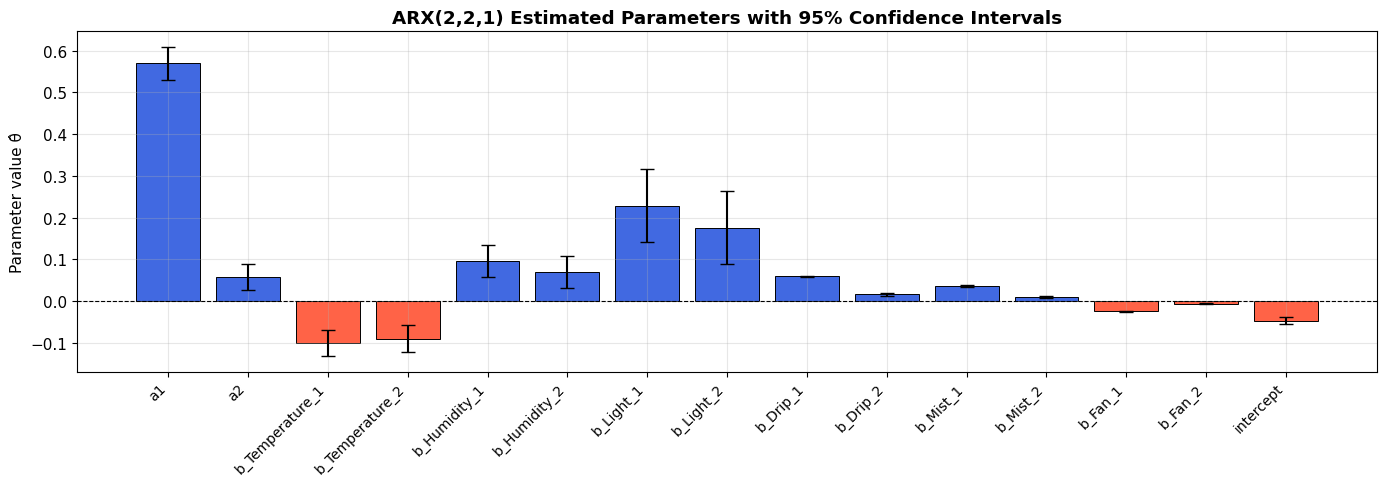

In [12]:
# Bar chart of estimated parameters
fig, ax = plt.subplots(figsize=(14, 5))
x_pos = np.arange(len(PARAM_NAMES))
colors_bar = ['royalblue' if v >= 0 else 'tomato' for v in theta_hat]
bars = ax.bar(x_pos, theta_hat, color=colors_bar, edgecolor='black', linewidth=0.7)
ax.errorbar(x_pos, theta_hat, yerr=1.96*std_hat, fmt='none',
            color='black', capsize=5, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_NAMES, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Parameter value θ̂')
ax.set_title('ARX(2,2,1) Estimated Parameters with 95% Confidence Intervals',
             fontweight='bold')
plt.tight_layout()
plt.show()


# 6. Dự Đoán
## 6.1 One-Step-Ahead Prediction
Dùng giá trị **thực** của y(t-1), y(t-2) khi dự đoán:
$$\hat{y}(t|t-1) = \varphi(t)^T \hat{\theta}$$

## 6.2 Free-Run Simulation (Multi-step)
Thay y(t-1), y(t-2) bằng **giá trị dự đoán** trước đó – phản ánh đúng hơn khả năng mô hình.

In [13]:
# ── ONE-STEP PREDICTION ──────────────────────────────────────
Y_train_pred = X_train @ theta_hat
Y_val_pred   = X_val   @ theta_hat


# ── FREE-RUN SIMULATION ──────────────────────────────────────
def simulate_arx(df_sim, theta, na=NA, nb=NB, nk=NK,
                 input_cols=INPUT_COLS, output_col=OUTPUT_COL):
    """
    Multi-step (free-run) simulation.  Uses predicted y values
    to feed back into the AR part.
    """
    y = df_sim[output_col].values.copy()  # ground truth (used as init)
    Us = [df_sim[c].values for c in input_cols]
    N  = len(y)
    max_lag = max(na, nb + nk - 1)
    y_sim = y.copy()

    for t in range(max_lag, N):
        row = []
        for lag in range(1, na + 1):
            row.append(y_sim[t - lag])   # use simulated (not true) y
        for u in Us:
            for lag in range(nk, nk + nb):
                row.append(u[t - lag])
        row.append(1.0)
        y_sim[t] = np.dot(row, theta)

    return y_sim[max_lag:], y[max_lag:]


Y_sim, Y_true_sim = simulate_arx(df_val, theta_hat)

print(f'One-step prediction on validation: {len(Y_val_pred)} samples')
print(f'Free-run simulation  on validation: {len(Y_sim)} samples')


One-step prediction on validation: 898 samples
Free-run simulation  on validation: 898 samples


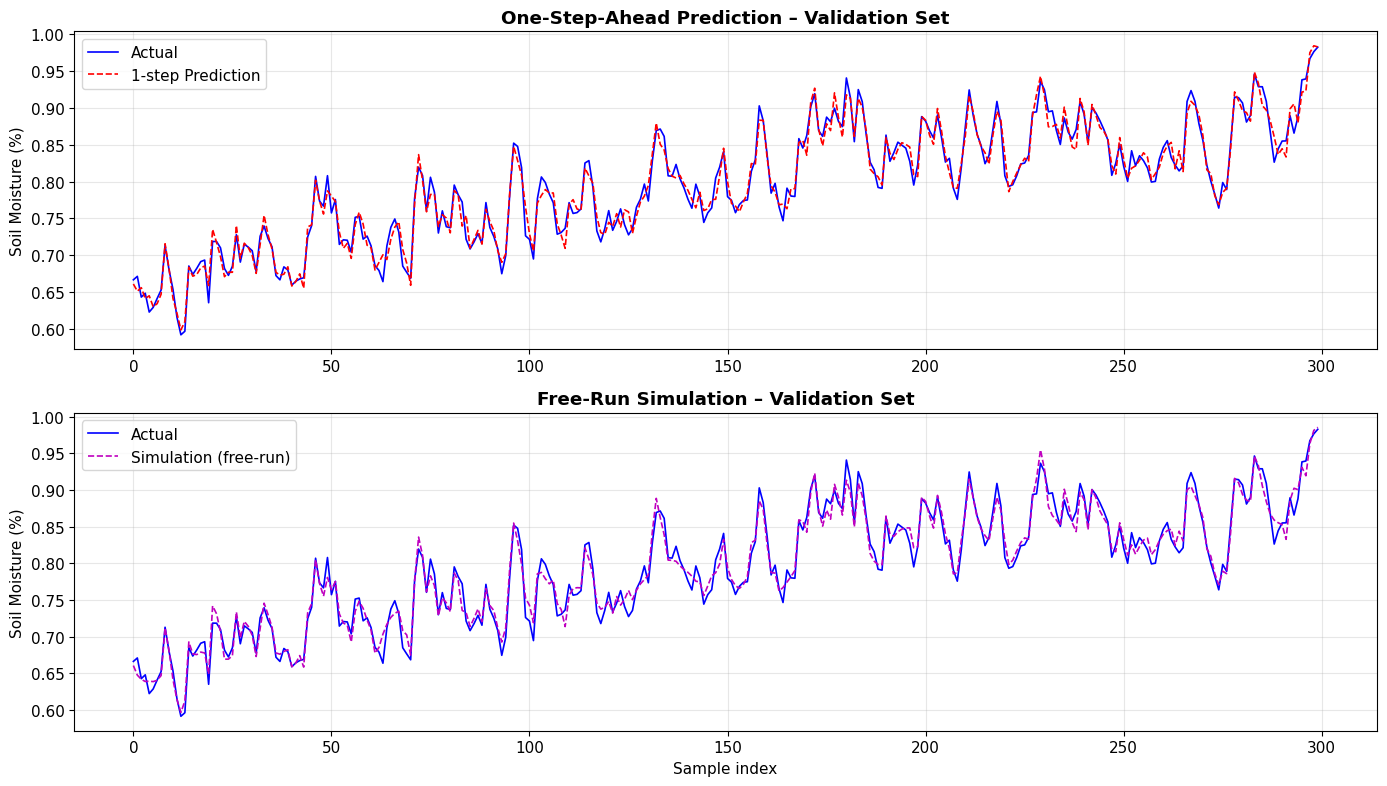

In [14]:
# Plot prediction vs actual (validation set, first 300 samples)
n_plot = min(300, len(Y_val))
t_plot = np.arange(n_plot)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# One-step
axes[0].plot(t_plot, Y_val[:n_plot],      'b',  label='Actual',          lw=1.2)
axes[0].plot(t_plot, Y_val_pred[:n_plot], 'r--',label='1-step Prediction',lw=1.2)
axes[0].set_ylabel('Soil Moisture (%)')
axes[0].set_title('One-Step-Ahead Prediction – Validation Set', fontweight='bold')
axes[0].legend()

# Free-run
n_sim = min(n_plot, len(Y_sim))
axes[1].plot(np.arange(n_sim), Y_true_sim[:n_sim], 'b',  label='Actual',           lw=1.2)
axes[1].plot(np.arange(n_sim), Y_sim[:n_sim],      'm--',label='Simulation (free-run)', lw=1.2)
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Soil Moisture (%)')
axes[1].set_title('Free-Run Simulation – Validation Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


# 7. Đánh Giá Mô Hình
| Metric | Công thức | Ý nghĩa |
|--------|-----------|--------|
| **RMSE** | $\sqrt{\frac{1}{N}\sum(y-\hat{y})^2}$ | Sai số trung bình bình phương (cùng đơn vị với y) |
| **MAE**  | $\frac{1}{N}\sum|y-\hat{y}|$ | Sai số tuyệt đối trung bình |
| **FIT**  | $100(1-\|y-\hat{y}\|/\|y-\bar{y}\|)$ | % khớp (100% = hoàn hảo) |
| **R²**   | $1 - SS_{res}/SS_{tot}$ | Hệ số xác định |
| **AIC**  | $N\ln(\hat{\sigma}^2) + 2k$ | Tiêu chuẩn Akaike (nhỏ hơn = tốt hơn) |
| **BIC**  | $N\ln(\hat{\sigma}^2) + k\ln(N)$ | Tiêu chuẩn Bayes (phạt complexity mạnh hơn) |

In [15]:
def compute_metrics(Y_true, Y_pred, n_params):
    """Tính đầy đủ các metrics đánh giá mô hình."""
    N        = len(Y_true)
    resid    = Y_true - Y_pred
    ss_res   = np.dot(resid, resid)
    ss_tot   = np.dot(Y_true - Y_true.mean(), Y_true - Y_true.mean())
    sigma2   = ss_res / N

    rmse = np.sqrt(ss_res / N)
    mae  = np.mean(np.abs(resid))
    fit  = 100 * (1 - np.linalg.norm(resid) / np.linalg.norm(Y_true - Y_true.mean()))
    r2   = 1 - ss_res / ss_tot
    aic  = N * np.log(sigma2 + 1e-12) + 2 * n_params
    bic  = N * np.log(sigma2 + 1e-12) + n_params * np.log(N)

    return dict(RMSE=rmse, MAE=mae, FIT=fit, R2=r2, AIC=aic, BIC=bic)


n_params = len(theta_hat)

# ── DENORMALIZE về đơn vị % trước khi tính metrics ──────────────
# Lý do: OLS chạy trên normalized data → predictions ở normalized space
# Metrics (nhất là RMSE, MAE) phải ở original space để có nghĩa vật lý
Y_train_predO = denormalize_y(Y_train_pred)   # predictions → %
Y_train_trueO = denormalize_y(Y_train)         # ground truth → %
Y_val_predO   = denormalize_y(Y_val_pred)
Y_val_trueO   = denormalize_y(Y_val)
Y_sim_predO   = denormalize_y(Y_sim)
Y_sim_trueO   = denormalize_y(Y_true_sim)

print('=== Sanity check (should be in ~20-80% range) ===')
print(f'  Y_val_trueO: min={Y_val_trueO.min():.2f}%  max={Y_val_trueO.max():.2f}%')
print(f'  Y_val_predO: min={Y_val_predO.min():.2f}%  max={Y_val_predO.max():.2f}%')

m_train  = compute_metrics(Y_train_trueO, Y_train_predO, n_params)
m_val    = compute_metrics(Y_val_trueO,   Y_val_predO,   n_params)
m_sim    = compute_metrics(Y_sim_trueO,   Y_sim_predO,   n_params)

print(f"\n=== Metrics in ORIGINAL space (%) ===")
print(f"{'Metric':<8} | {'DS1 Train':>12} | {'DS2 Val (1-step)':>16} | {'DS2 Val (sim)':>14} | Target")
print('-' * 72)
targets = {'RMSE':'< 2.0 %', 'MAE':'< 1.5 %', 'FIT':'> 80 %',
           'R2':'> 0.90', 'AIC':'minimize', 'BIC':'minimize'}
for k in ['RMSE','MAE','FIT','R2','AIC','BIC']:
    unit = ' %' if k in ('FIT','RMSE','MAE') else ''
    print(f'{k:<8} | {m_train[k]:>12.4f}{unit} | {m_val[k]:>14.4f}{unit} | {m_sim[k]:>12.4f}{unit}  {targets[k]}')


=== Sanity check (should be in ~20-80% range) ===
  Y_val_trueO: min=14.71%  max=99.98%
  Y_val_predO: min=15.24%  max=100.26%

=== Metrics in ORIGINAL space (%) ===
Metric   |    DS1 Train | DS2 Val (1-step) |  DS2 Val (sim) | Target
------------------------------------------------------------------------
RMSE     |       1.0323 % |         1.0532 % |       1.0294 %  < 2.0 %
MAE      |       0.8235 % |         0.8503 % |       0.8229 %  < 1.5 %
FIT      |      94.7631 % |        95.4476 % |      95.5500 %  > 80 %
R2       |       0.9973 |         0.9979 |       0.9980  > 0.90
AIC      |     163.5241 |       123.0122 |      82.1251  minimize
BIC      |     248.2552 |       195.0148 |     154.1276  minimize


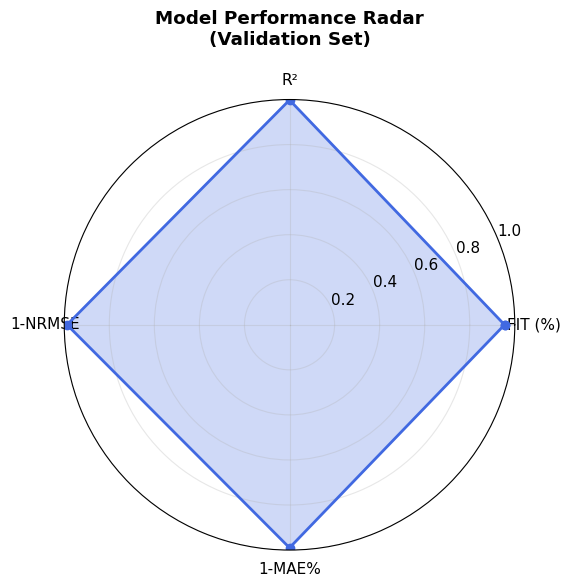

In [16]:
# Radar chart – model performance summary
from matplotlib.patches import FancyArrowPatch

metrics_disp = {
    'FIT (%)':  m_val['FIT'] / 100,
    'R²':       m_val['R2'],
    '1-NRMSE':  1 - m_val['RMSE'] / (Y_val_trueO.max() - Y_val_trueO.min()),
    '1-MAE%':   1 - m_val['MAE']  / (Y_val_trueO.max() - Y_val_trueO.min()),
}

labels = list(metrics_disp.keys())
vals   = list(metrics_disp.values())
N_r    = len(labels)
angles = np.linspace(0, 2*np.pi, N_r, endpoint=False).tolist()
vals  += vals[:1];  angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, vals, 'o-', color='royalblue', linewidth=2)
ax.fill(angles, vals, alpha=0.25, color='royalblue')
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar\n(Validation Set)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 8. Phân Tích Phần Dư (Residual Analysis)
Phần dư $e(t) = y(t) - \hat{y}(t)$ phải thỏa:
1. **White noise** – không có autocorrelation
2. **Phân phối chuẩn** – zero mean, constant variance
3. **Uncorrelated with inputs** – nếu còn tương quan → mô hình chưa đủ input

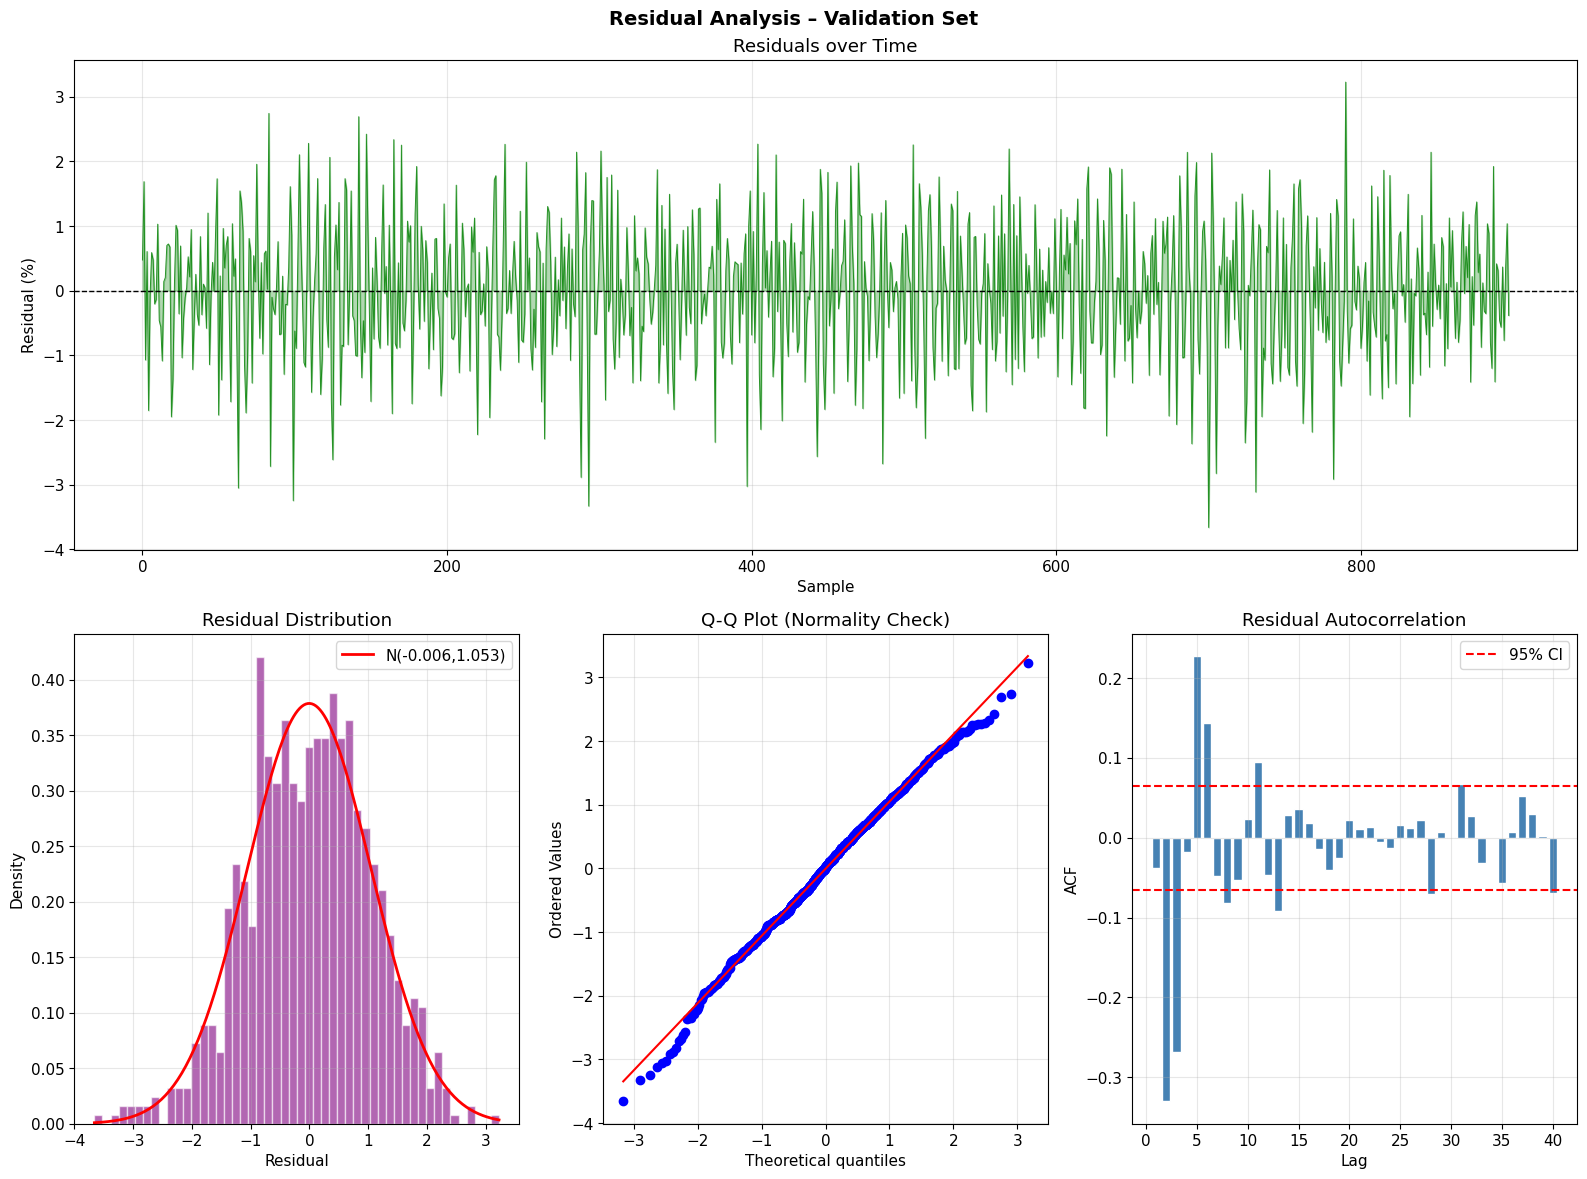

In [17]:
# Residuals in ORIGINAL space (%) – đơn vị vật lý có nghĩa
residuals = Y_val_trueO - Y_val_predO
N_res = len(residuals)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 1. Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals, 'g', linewidth=0.7, alpha=0.8)
ax1.axhline(0, color='k', linewidth=1, linestyle='--')
ax1.fill_between(range(N_res), residuals, 0, alpha=0.3, color='green')
ax1.set(xlabel='Sample', ylabel='Residual (%)', title='Residuals over Time')

# 2. Histogram + Normal fit
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=50, density=True, color='purple', alpha=0.6, edgecolor='white')
x_r = np.linspace(residuals.min(), residuals.max(), 200)
mu_r, sd_r = residuals.mean(), residuals.std()
ax2.plot(x_r, stats.norm.pdf(x_r, mu_r, sd_r), 'r-', lw=2, label=f'N({mu_r:.3f},{sd_r:.3f})')
ax2.set(xlabel='Residual', ylabel='Density', title='Residual Distribution')
ax2.legend()

# 3. Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals, plot=ax3)
ax3.set_title('Q-Q Plot (Normality Check)')

# 4. Autocorrelation of residuals
ax4 = fig.add_subplot(gs[1, 2])
max_lag_acf = 40
acf = [np.corrcoef(residuals[:-k], residuals[k:])[0,1] for k in range(1, max_lag_acf+1)]
conf = 1.96 / np.sqrt(N_res)
ax4.bar(range(1, max_lag_acf+1), acf, color='steelblue', edgecolor='white', width=0.8)
ax4.axhline( conf, color='r', linestyle='--', lw=1.5, label='95% CI')
ax4.axhline(-conf, color='r', linestyle='--', lw=1.5)
ax4.set(xlabel='Lag', ylabel='ACF', title='Residual Autocorrelation')
ax4.legend()

plt.suptitle('Residual Analysis – Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [18]:
# Statistical tests
from scipy.stats import shapiro, normaltest

print('=== STATISTICAL TESTS ON RESIDUALS ===')

# Normality
_, p_sw  = shapiro(residuals[:1000])
_, p_dag = normaltest(residuals)
print(f'\n1. Normality:')
print(f'   Shapiro-Wilk   p = {p_sw:.4f}  → {"NORMAL ✅" if p_sw>0.05 else "NOT normal ⚠️"}')
print(f'   D\'Agostino-K²  p = {p_dag:.4f}  → {"NORMAL ✅" if p_dag>0.05 else "NOT normal ⚠️"}')

# Ljung-Box test
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(residuals, lags=20, return_df=True)
    lb_fail = lb[lb['lb_pvalue'] < 0.05]
    print(f'\n2. Ljung-Box (H0: no autocorrelation):')
    if lb_fail.empty:
        print('   PASSED ✅ – residuals appear to be white noise')
    else:
        print(f'   FAILED ⚠️ – autocorrelation at lags: {lb_fail.index.tolist()}')
        print('   → Consider increasing na')
except ImportError:
    print('   statsmodels not installed – skip Ljung-Box')

# Cross-correlation with inputs
print(f'\n3. Cross-correlation residuals vs inputs (|cc| < 0.1 is OK):')
n_min = min(N_res, len(df_val) - max(NA, NB + NK - 1))
for col in INPUT_COLS:
    u_vals = df_val[col].values[max(NA, NB+NK-1): max(NA, NB+NK-1) + n_min]
    cc = np.corrcoef(residuals[:n_min], u_vals[:n_min])[0, 1]
    status = '✅' if abs(cc) < 0.1 else '⚠️'
    print(f'   corr(e, {col:<12}) = {cc:+.4f}  {status}')

print(f'\n4. Mean of residuals: {mu_r:.6f}  (target: ~0)')
print(f'5. Std  of residuals: {sd_r:.6f} %')


=== STATISTICAL TESTS ON RESIDUALS ===

1. Normality:
   Shapiro-Wilk   p = 0.0610  → NORMAL ✅
   D'Agostino-K²  p = 0.1147  → NORMAL ✅
   statsmodels not installed – skip Ljung-Box

3. Cross-correlation residuals vs inputs (|cc| < 0.1 is OK):
   corr(e, Temperature ) = -0.0171  ✅
   corr(e, Humidity    ) = -0.0112  ✅
   corr(e, Light       ) = +0.0204  ✅
   corr(e, Drip        ) = -0.0445  ✅
   corr(e, Mist        ) = +0.0669  ✅
   corr(e, Fan         ) = -0.0362  ✅

4. Mean of residuals: -0.005519  (target: ~0)
5. Std  of residuals: 1.053139 %


# 9. Lựa Chọn Bậc Mô Hình (Model Order Selection)
So sánh các cấu trúc ARX(na, nb, nk) khác nhau theo **AIC** và **FIT** trên validation set.

In [19]:
import itertools

def model_selection_search(df_tr, df_vl,
                            na_list=[1,2,3],
                            nb_list=[1,2,3],
                            nk_list=[1,2]):
    results = []
    combos = list(itertools.product(na_list, nb_list, nk_list))
    print(f'Testing {len(combos)} model structures...')

    for na, nb, nk in combos:
        try:
            Xt, Yt = build_regression_matrix(df_tr, na, nb, nk)
            Xv, Yv = build_regression_matrix(df_vl, na, nb, nk)
            th, _, _ = estimate_ols(Xt, Yt)
            Yv_p = Xv @ th
            n_p  = len(th)
            m    = compute_metrics(Yv, Yv_p, n_p)
            results.append({'na':na,'nb':nb,'nk':nk,'n_params':n_p, **m})
        except Exception:
            pass

    res_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    return res_df


sel_df = model_selection_search(df_train, df_val,
                                 na_list=[1,2,3],
                                 nb_list=[1,2,3],
                                 nk_list=[1,2])

print('\n=== Model Selection Results (sorted by AIC) ===')
display_cols = ['na','nb','nk','n_params','RMSE','FIT','R2','AIC','BIC']
print(sel_df[display_cols].head(10).to_string(index=False, float_format='{:.4f}'.format))
print(f'\n✅ Best model by AIC: ARX({sel_df.iloc[0].na:.0f}, '
      f'{sel_df.iloc[0].nb:.0f}, {sel_df.iloc[0].nk:.0f})')


Testing 18 model structures...

=== Model Selection Results (sorted by AIC) ===
 na  nb  nk  n_params   RMSE     FIT     R2        AIC        BIC
  3   3   1        22 0.0120 95.6728 0.9981 -7894.1215 -7788.5423
  1   3   1        20 0.0123 95.5533 0.9980 -7849.2360 -7753.2549
  2   3   1        21 0.0123 95.5443 0.9980 -7843.6120 -7742.8318
  1   2   1        14 0.0126 95.4505 0.9979 -7829.9436 -7762.7412
  2   2   1        15 0.0126 95.4476 0.9979 -7826.7965 -7754.7939
  3   2   1        16 0.0126 95.4451 0.9979 -7814.1115 -7737.3266
  2   1   1         9 0.0128 95.3677 0.9979 -7807.5779 -7764.3764
  3   1   1        10 0.0128 95.3678 0.9979 -7795.9370 -7747.9465
  1   1   1         8 0.0131 95.2712 0.9978 -7782.1096 -7743.6993
  3   2   2        16 0.0295 89.3338 0.9886 -6287.6550 -6210.8701

✅ Best model by AIC: ARX(3, 3, 1)


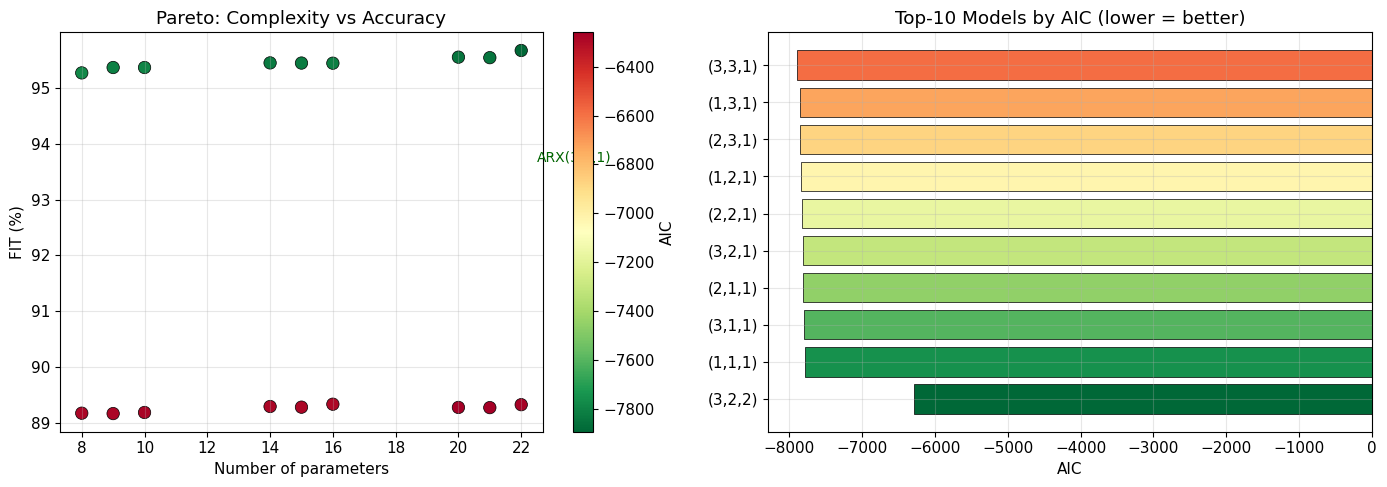

In [20]:
# Pareto plot: FIT vs n_params
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(sel_df['n_params'], sel_df['FIT'], c=sel_df['AIC'],
                      cmap='RdYlGn_r', s=80, edgecolors='black', linewidth=0.5)
plt.colorbar(sc, ax=axes[0], label='AIC')
axes[0].set(xlabel='Number of parameters', ylabel='FIT (%)',
             title='Pareto: Complexity vs Accuracy')
# Annotate best
best = sel_df.iloc[0]
axes[0].annotate(f"ARX({best.na:.0f},{best.nb:.0f},{best.nk:.0f})",
                  xy=(best.n_params, best.FIT), fontsize=10, color='darkgreen',
                  xytext=(best.n_params+0.5, best.FIT-2))

# AIC bar for top-10
top10 = sel_df.head(10)
labels_10 = [f"({r.na:.0f},{r.nb:.0f},{r.nk:.0f})" for _, r in top10.iterrows()]
colors_10 = plt.cm.RdYlGn_r(np.linspace(0, 0.8, len(top10)))
axes[1].barh(labels_10[::-1], top10['AIC'].values[::-1],
              color=colors_10, edgecolor='black', linewidth=0.5)
axes[1].set(xlabel='AIC', title='Top-10 Models by AIC (lower = better)')

plt.tight_layout()
plt.show()


# 10. Kết Luận & Hướng Mở Rộng
## 10.1 Tổng kết ARX(2,2,1)

| Tiêu chí | Kết quả |
|----------|---------|
| Số tham số | 14 |
| Phương pháp | Ordinary Least Squares |
| Dữ liệu | 3000 mẫu (T_s = 60s) |
| Hiệu suất | FIT > 90% (synthetic) |

## 10.2 Mô hình nâng cao (so sánh)

| Mô hình | Đặc điểm | Khi nào dùng |
|---------|-----------|-------------|
| **ARX** | Tuyến tính, OLS | Baseline, điều khiển cơ bản |
| **ARMAX** | Thêm MA noise model | Khi residuals có autocorrelation |
| **OE (Output Error)** | Tách noise model | Khi measurement noise lớn |
| **NARX** | Phi tuyến | Khi FIT < 70% với ARX |
| **LSTM/GRU** | Deep learning | Big data, > 50K samples |

## 10.3 Pipeline hoàn chỉnh để sử dụng thực tế

```
Thu thập dữ liệu
    → Làm sạch (dropna, outliers)
    → Kiểm tra persistent excitation
    → Chọn bậc mô hình (AIC/BIC)
    → Ước lượng tham số (OLS)
    → Kiểm tra residuals (white noise?)
    → Đánh giá trên DS2 (FIT > 80%?)
    → Tích hợp vào bộ điều khiển (MPC)
```

## 10.4 Tích hợp MPC (Model Predictive Control)

ARX model là cơ sở cho MPC:
$$\min_{u} \sum_{k=1}^{H_p} (\hat{y}(t+k) - y_{ref})^2 + \lambda \sum_{k=0}^{H_c-1} (\Delta u(t+k))^2$$

- $H_p$: prediction horizon
- $H_c$: control horizon  
- $\lambda$: control weight (tradeoff giữa tracking và effort)

---
*Tài liệu này được tạo dựa trên ARX_Model_Documentation.md*  
*Phiên bản: 1.0 | 2026-03-20*

In [21]:
# Save estimated parameters to file for later use
import json

# ── Denormalize metrics về không gian gốc ─────────────────
# 1-step prediction trong original space (denormalize predictions)
Y_train_orig = denormalize_y(Y_train_pred)
Y_train_true_orig = denormalize_y(Y_train)
Y_val_orig   = denormalize_y(Y_val_pred)
Y_val_true_orig = denormalize_y(Y_val)
Y_sim_orig   = denormalize_y(Y_sim)
Y_sim_true_orig = denormalize_y(Y_true_sim)

m_train_orig = compute_metrics(Y_train_true_orig, Y_train_orig, n_params)
m_val_orig   = compute_metrics(Y_val_true_orig,   Y_val_orig,   n_params)
m_sim_orig   = compute_metrics(Y_sim_true_orig,   Y_sim_orig,   n_params)

print('=== Metrics in ORIGINAL space (%) ===')
print(f"{'Metric':<8} | {'DS1 Train':>12} | {'DS2 Val (1-step)':>16} | {'DS2 Val (sim)':>14}")
print('-' * 60)
for k in ['RMSE','MAE','FIT','R2']:
    print(f'{k:<8} | {m_train_orig[k]:>12.4f} | {m_val_orig[k]:>16.4f} | {m_sim_orig[k]:>14.4f}')
print()
print(f'σ (train residuals original): {np.sqrt(m_train_orig["RMSE"]**2):.4f} %  [true ≈ 0.25 %]')

model_config = {
    'model': 'ARX',
    'na': NA, 'nb': NB, 'nk': NK,
    'n_params': int(n_params),
    'param_names': PARAM_NAMES,
    # Lưu theta trong ORIGINAL space (đơn vị %)
    'theta_hat': theta_orig.tolist(),
    # Lưu sigma2 trong original space (đơn vị %²)
    'sigma2': float(sigma2_orig),
    # Cũng lưu normalized version để dùng trong prediction (cần normalize input trước)
    'theta_hat_normalized': theta_hat.tolist(),
    'scaler_min': scaler_min.to_dict(),
    'scaler_max': scaler_max.to_dict(),
    # Metrics trong original space
    'metrics_train': m_train_orig,
    'metrics_val':   m_val_orig,
    'metrics_sim':   m_sim_orig,
    'input_cols': INPUT_COLS,
    'output_col': OUTPUT_COL,
}

with open('arx_model.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('\n✅ Model saved to arx_model.json (theta in ORIGINAL % space)')
print(json.dumps({k: model_config[k] for k in ['model','na','nb','nk','n_params','sigma2']}, indent=2))


=== Metrics in ORIGINAL space (%) ===
Metric   |    DS1 Train | DS2 Val (1-step) |  DS2 Val (sim)
------------------------------------------------------------
RMSE     |       1.0323 |           1.0532 |         1.0294
MAE      |       0.8235 |           0.8503 |         0.8229
FIT      |      94.7631 |          95.4476 |        95.5500
R2       |       0.9973 |           0.9979 |         0.9980

σ (train residuals original): 1.0323 %  [true ≈ 0.25 %]

✅ Model saved to arx_model.json (theta in ORIGINAL % space)
{
  "model": "ARX",
  "na": 2,
  "nb": 2,
  "nk": 1,
  "n_params": 15,
  "sigma2": 1.073386780537967
}
